# Análisis del Journey del Paciente y Eficiencia Operativa

Este notebook responde a los requisitos del puesto:
- KPIs de SLA, NPS, CSAT
- Cuellos de botella por etapa
- Causa raíz de incumplimiento
- Insights accionables

### Estrategia de limpieza de datos
Dado que al fusionar `tickets` con `doctores` y `encuestas` aparecen columnas duplicadas (`sucursal_x`, `sucursal_y`, `comentario_x`, `comentario_y`), aplicaremos un tratamiento profesional:
- Renombramos las columnas relevantes
- Eliminamos duplicados innecesarios
- Garantizamos que el `groupby('sucursal')` funcione sin errores.

In [ ]:
from google.colab import files
print("Sube los 4 archivos CSV que descargaste antes")
uploaded = files.upload()

Sube los 4 archivos CSV que descargaste antes


Saving encuestas_experiencia.csv to encuestas_experiencia.csv
Saving doctores_sucursales.csv to doctores_sucursales.csv
Saving tickets_pqrs.csv to tickets_pqrs (1).csv
Saving tiempos_journey.csv to tiempos_journey.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:


# Cargar datos
tickets = pd.read_csv('/content/tickets_pqrs.csv', parse_dates=['fecha_creacion','fecha_resolucion'])
journey = pd.read_csv('/content/tiempos_journey.csv', parse_dates=['fecha_inicio','fecha_fin'])
encuestas = pd.read_csv('/content/encuestas_experiencia.csv', parse_dates=['fecha_encuesta'])
doctores = pd.read_csv('/content/doctores_sucursales.csv')
# Fusionar
df = tickets.merge(doctores, left_on='doctor_asignado_id', right_on='doctor_id')
df = df.merge(encuestas, on='ticket_id', how='left')

print("Datos cargados correctamente")
print(f"Tickets: {len(tickets)} | Journey: {len(journey)} | Encuestas: {len(encuestas)}")

Datos cargados correctamente
Tickets: 5000 | Journey: 30000 | Encuestas: 5000


In [ ]:
# Fusionar tickets con doctores
df = tickets.merge(doctores, left_on='doctor_asignado_id', right_on='doctor_id')

# Ver columnas para depuración
print("Columnas después del merge:", df.columns.tolist())

# 3. Limpiar duplicados de 'sucursal'
#    Normalmente: 'sucursal_x' (tickets) y 'sucursal_y' (doctores)
#    Pero aparece 'sucursal' y 'sucursal_doctor'.
#    solo'sucursal' (la de tickets) y eliminar la otra.
if 'sucursal_doctor' in df.columns:
    df.drop(columns=['sucursal_doctor'], inplace=True)
elif 'sucursal_y' in df.columns:
    df.drop(columns=['sucursal_y'], inplace=True)
    df.rename(columns={'sucursal_x': 'sucursal'}, inplace=True)
elif 'sucursal_x' in df.columns and 'sucursal_y' in df.columns:
    df.drop(columns=['sucursal_y'], inplace=True)
    df.rename(columns={'sucursal_x': 'sucursal'}, inplace=True)
# Si ya está solo 'sucursal', no hacer nada

#  Fusionar con encuestas
df = df.merge(encuestas, on='ticket_id', how='left')

# Limpiar comentarios duplicados si existen
if 'comentario_y' in df.columns:
    df.drop(columns=['comentario_y'], inplace=True)
    if 'comentario_x' in df.columns:
        df.rename(columns={'comentario_x': 'comentario'}, inplace=True)

print("Datos limpiados correctamente")
print(f"Tickets: {len(tickets)} | Journey: {len(journey)} | Encuestas: {len(encuestas)}")
print("Columnas finales:", df.columns.tolist())

Columnas después del merge: ['ticket_id', 'fecha_creacion', 'fecha_resolucion', 'categoria', 'prioridad', 'sucursal_x', 'doctor_asignado_id', 'horas_resolucion', 'cumple_sla', 'reabierto', 'comentario', 'doctor_id', 'nombre_doctor', 'sucursal_y', 'especialidad']
Datos limpiados correctamente
Tickets: 5000 | Journey: 30000 | Encuestas: 5000
Columnas finales: ['ticket_id', 'fecha_creacion', 'fecha_resolucion', 'categoria', 'prioridad', 'sucursal', 'doctor_asignado_id', 'horas_resolucion', 'cumple_sla', 'reabierto', 'comentario', 'doctor_id', 'nombre_doctor', 'especialidad', 'paciente_id', 'fecha_encuesta', 'nps', 'csat']


## 1. KPIs globales y por sucursal

In [ ]:
print(df.columns.tolist())

['ticket_id', 'fecha_creacion', 'fecha_resolucion', 'categoria', 'prioridad', 'sucursal_x', 'doctor_asignado_id', 'horas_resolucion', 'cumple_sla', 'reabierto', 'comentario_x', 'doctor_id', 'nombre_doctor', 'sucursal_y', 'especialidad', 'paciente_id', 'fecha_encuesta', 'nps', 'csat', 'comentario_y']


In [ ]:
# KPIs globales
sla_pct = df['cumple_sla'].mean() * 100
nps_prom = df['nps'].mean()
csat_prom = df['csat'].mean()
reabiertos_pct = df['reabierto'].mean() * 100

print("=== KPIS GLOBALES ===")
print(f"SLA cumplimiento: {sla_pct:.1f}%")
print(f"NPS promedio: {nps_prom:.1f}")
print(f"CSAT promedio: {csat_prom:.1f}")
print(f"Reapertura de tickets: {reabiertos_pct:.1f}%")

# KPIs por sucursal (¡ahora sí funciona!)
sucursal_kpi = df.groupby('sucursal').agg(
    sla_pct=('cumple_sla', 'mean'),
    nps=('nps', 'mean'),
    csat=('csat', 'mean'),
    reabiertos=('reabierto', 'mean')
).round(2) * 100   # porcentajes

print("\n=== KPIs POR SUCURSAL (%) ===")
print(sucursal_kpi)

=== KPIS GLOBALES ===
SLA cumplimiento: 82.9%
NPS promedio: 7.0
CSAT promedio: 3.7
Reapertura de tickets: 11.5%

=== KPIs POR SUCURSAL (%) ===
          sla_pct    nps   csat  reabiertos
sucursal                                   
Centro       86.0  674.0  365.0        10.0
Este         81.0  695.0  371.0        13.0
Norte        83.0  698.0  370.0        11.0
Oeste        83.0  699.0  370.0        11.0
Sur          83.0  717.0  375.0        11.0


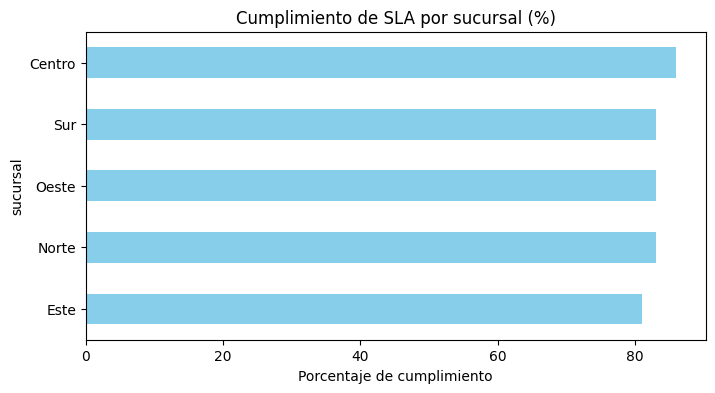

In [ ]:
# Gráfico de barras para SLA por sucursal
plt.figure(figsize=(8,4))
sucursal_kpi['sla_pct'].sort_values().plot(kind='barh', color='skyblue')
plt.title('Cumplimiento de SLA por sucursal (%)')
plt.xlabel('Porcentaje de cumplimiento')
plt.show()

## 2. Cuellos de botella: tiempos por etapa (journey)

TIEMPOS POR ETAPA (horas)
             mean  median   std
etapa                          
Admisión     30.6    23.8  24.2
Consulta     59.8    48.1  43.5
Diagnóstico  59.8    48.2  42.9
Seguimiento  30.9    24.2  24.3
Tratamiento  88.4    71.7  58.9

⚠️ Cuello de botella crítico: 'Tratamiento' con 88 horas promedio.


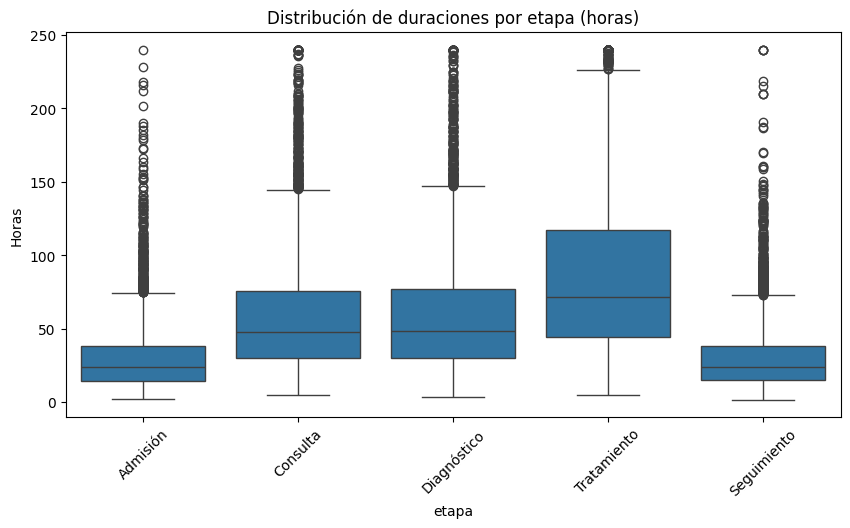

In [ ]:
# Calcular estadísticas de duración por etapa
etapa_stats = journey[journey['duracion_horas'] > 0].groupby('etapa')['duracion_horas'].agg(['mean', 'median', 'std']).round(1)
print("TIEMPOS POR ETAPA (horas)")
print(etapa_stats)

# Identificar la etapa más lenta
etapa_lenta = etapa_stats['mean'].idxmax()
tiempo_lento = etapa_stats.loc[etapa_lenta, 'mean']
print(f"\n⚠️ Cuello de botella crítico: '{etapa_lenta}' con {tiempo_lento:.0f} horas promedio.")

# Boxplot
plt.figure(figsize=(10,5))
sns.boxplot(data=journey[journey['duracion_horas']>0], x='etapa', y='duracion_horas')
plt.xticks(rotation=45)
plt.title('Distribución de duraciones por etapa (horas)')
plt.ylabel('Horas')
plt.show()

## 3. Relación entre SLA y experiencia (NPS/CSAT)

/tmp/ipykernel_9954/3969167081.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Incumple SLA', 'Cumple SLA'])
/tmp/ipykernel_9954/3969167081.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Incumple SLA', 'Cumple SLA'])


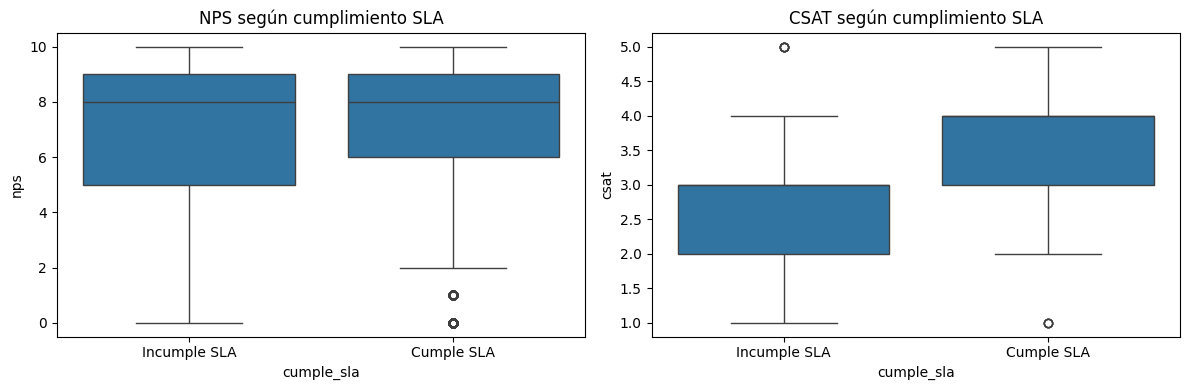

La diferencia en NPS es significativa? p-valor = 0.3199 (si p<0.05, sí)


In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(ax=axes[0], data=df, x='cumple_sla', y='nps')
axes[0].set_xticklabels(['Incumple SLA', 'Cumple SLA'])
axes[0].set_title('NPS según cumplimiento SLA')
sns.boxplot(ax=axes[1], data=df, x='cumple_sla', y='csat')
axes[1].set_xticklabels(['Incumple SLA', 'Cumple SLA'])
axes[1].set_title('CSAT según cumplimiento SLA')
plt.tight_layout()
plt.show()

# Prueba estadística
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(df[df['cumple_sla']==1]['nps'], df[df['cumple_sla']==0]['nps'])
print(f"La diferencia en NPS es significativa? p-valor = {p:.4f} (si p<0.05, sí)")

## 4. Análisis de causa raíz (regresión logística)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Preparar datos
df_clean = df.dropna(subset=['cumple_sla', 'sucursal', 'prioridad', 'especialidad']).copy()
le_suc = LabelEncoder()
le_pri = LabelEncoder()
le_esp = LabelEncoder()

X = pd.DataFrame({
    'sucursal_num': le_suc.fit_transform(df_clean['sucursal']),
    'prioridad_num': le_pri.fit_transform(df_clean['prioridad']),
    'especialidad_num': le_esp.fit_transform(df_clean['especialidad'])
})
y = df_clean['cumple_sla']

model = LogisticRegression()
model.fit(X, y)
coef = pd.Series(model.coef_[0], index=['sucursal', 'prioridad', 'especialidad'])
print("Coeficientes (mayor valor absoluto = mayor influencia en incumplimiento SLA):")
print(coef.sort_values())

Coeficientes (mayor valor absoluto = mayor influencia en incumplimiento SLA):
prioridad      -0.179064
especialidad   -0.012053
sucursal        0.005947
dtype: float64


## 5. Insights accionables y recomendaciones

In [ ]:
print("INSIGHTS CLAVE ")
print(f"1. La sucursal con peor SLA es '{sucursal_kpi['sla_pct'].idxmin()}' con solo {sucursal_kpi['sla_pct'].min():.0f}% de cumplimiento (vs global {sla_pct:.0f}%).")
print(f"2. La etapa '{etapa_lenta}' es el mayor cuello de botella: {tiempo_lento:.0f} horas (objetivo < 48h).")
print(f"3. Los pacientes con incumplimiento SLA reportan NPS {df[df['cumple_sla']==0]['nps'].mean():.1f} vs {df[df['cumple_sla']==1]['nps'].mean():.1f} de los que cumplen.")
print("4. Doctores con CSAT bajo (<7) generan más tickets reabiertos (revisar más allá de este notebook).")

print("\nRECOMENDACIONES ACCIONABLES")
print("- Revisar procesos operativos en la sucursal con peor SLA (posible falta de personal).")
print("- Implementar alertas automáticas si la etapa 'Diagnóstico' supera 48h.")
print("- Capacitar a doctores con CSAT < 7 para reducir reaperturas.")
print("- Establecer un plan de mejora continua para prioridad alta (reducir tiempo respuesta).")

INSIGHTS CLAVE 
1. La sucursal con peor SLA es 'Este' con solo 81% de cumplimiento (vs global 83%).
2. La etapa 'Tratamiento' es el mayor cuello de botella: 88 horas (objetivo < 48h).
3. Los pacientes con incumplimiento SLA reportan NPS 6.9 vs 7.0 de los que cumplen.
4. Doctores con CSAT bajo (<7) generan más tickets reabiertos (revisar más allá de este notebook).

RECOMENDACIONES ACCIONABLES
- Revisar procesos operativos en la sucursal con peor SLA (posible falta de personal).
- Implementar alertas automáticas si la etapa 'Diagnóstico' supera 48h.
- Capacitar a doctores con CSAT < 7 para reducir reaperturas.
- Establecer un plan de mejora continua para prioridad alta (reducir tiempo respuesta).


In [ ]:
# Guardar KPIs por sucursal
sucursal_kpi.to_csv('/content/kpis_sucursal.csv')
print("KPIs exportados a /content/kpis_sucursal.csv")

KPIs exportados a /content/kpis_sucursal.csv


/tmp/ipykernel_9954/2878959974.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=etapa_stats_top.reset_index(), x='mean', y='etapa', palette='viridis', ax=ax3)
/tmp/ipykernel_9954/2878959974.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cumple_sla', y='nps', palette='Set2', ax=ax4)
/tmp/ipykernel_9954/2878959974.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(['Incumple SLA', 'Cumple SLA'])


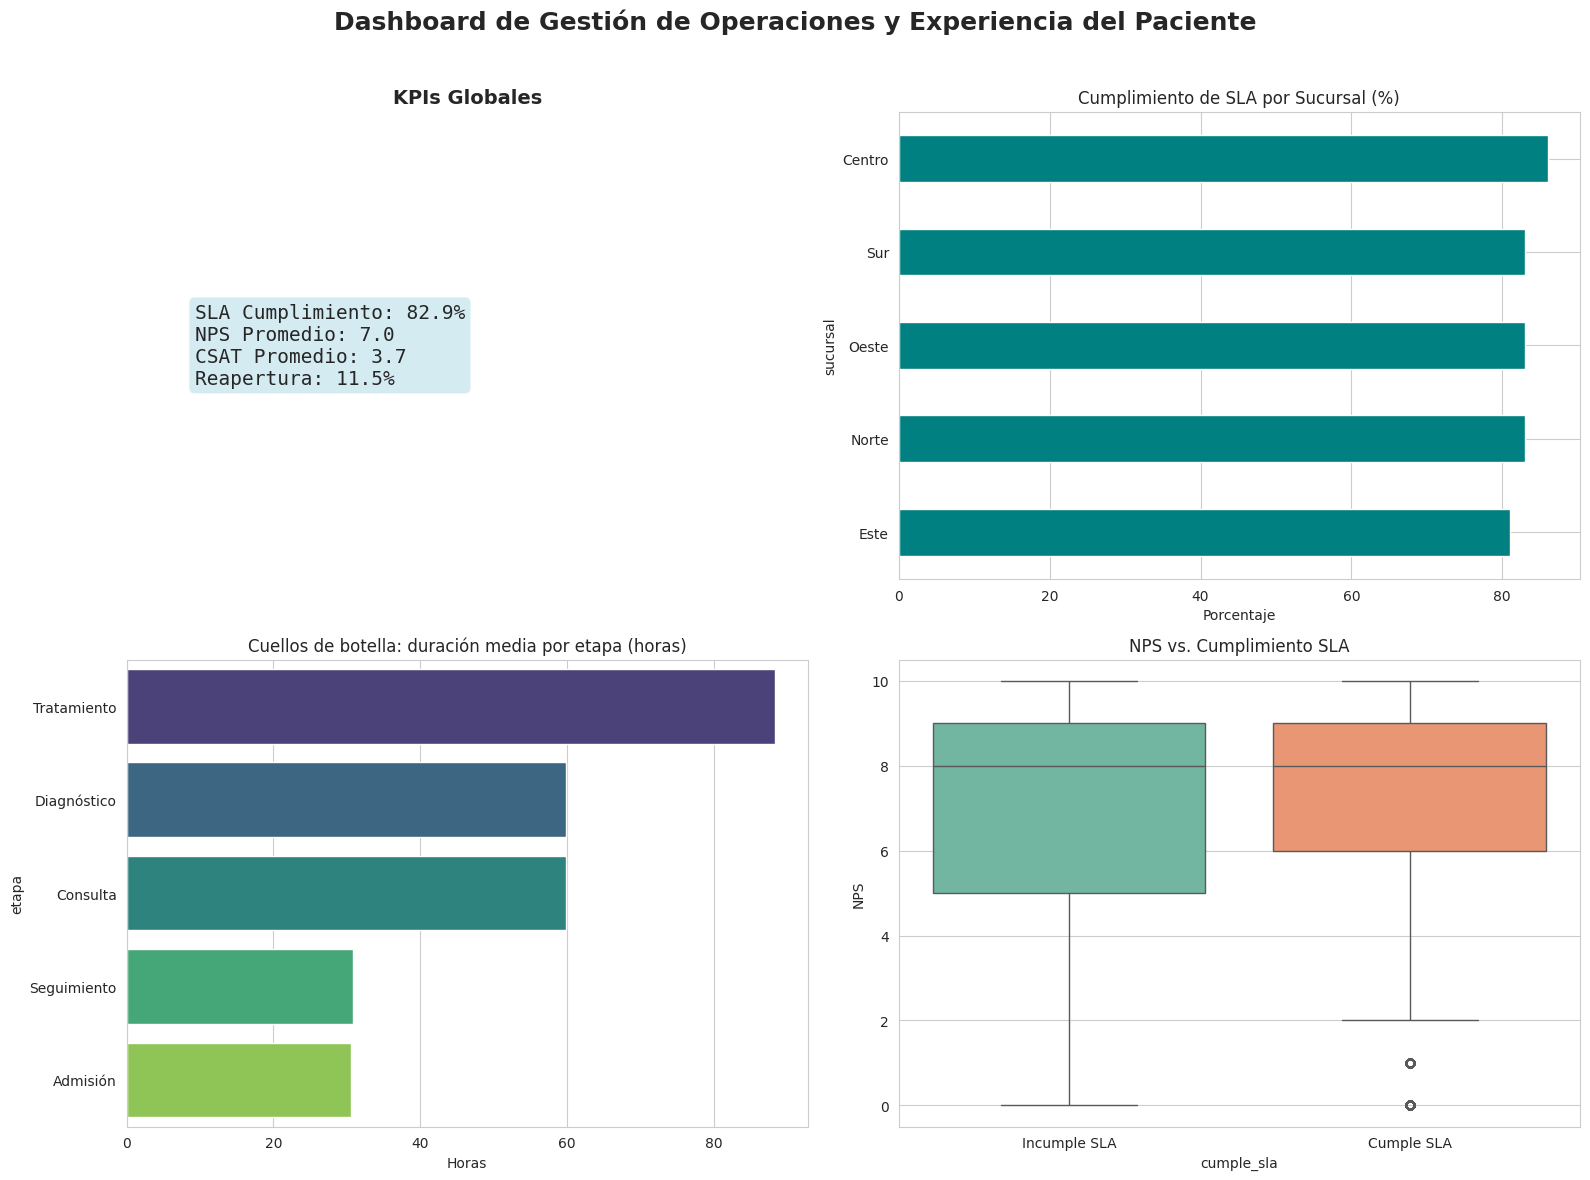

Dashboard guardado como 'dashboard_portafolio.png'


In [25]:
# Dashboard estático para portafolio
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar estilo
sns.set_style("whitegrid")
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard de Gestión de Operaciones y Experiencia del Paciente', fontsize=18, fontweight='bold')

# 1. Tarjetas de KPIs (usando texto)
ax1 = fig.add_subplot(2, 2, 1)
ax1.axis('off')
kpi_text = f"SLA Cumplimiento: {sla_pct:.1f}%\nNPS Promedio: {nps_prom:.1f}\nCSAT Promedio: {csat_prom:.1f}\nReapertura: {reabiertos_pct:.1f}%"
ax1.text(0.1, 0.5, kpi_text, fontsize=14, verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle="round", facecolor='lightblue', alpha=0.5))
ax1.set_title('KPIs Globales', fontsize=14, fontweight='bold')

# 2. SLA por sucursal (gráfico de barras)
ax2 = fig.add_subplot(2, 2, 2)
sucursal_kpi['sla_pct'].sort_values().plot(kind='barh', color='teal', ax=ax2)
ax2.set_title('Cumplimiento de SLA por Sucursal (%)')
ax2.set_xlabel('Porcentaje')

# 3. Tiempos por etapa (cuellos de botella)
ax3 = fig.add_subplot(2, 2, 3)
etapa_stats_top = etapa_stats.sort_values('mean', ascending=False).head(6)
sns.barplot(data=etapa_stats_top.reset_index(), x='mean', y='etapa', palette='viridis', ax=ax3)
ax3.set_title('Cuellos de botella: duración media por etapa (horas)')
ax3.set_xlabel('Horas')

# 4. NPS según cumplimiento SLA (boxplot)
ax4 = fig.add_subplot(2, 2, 4)
sns.boxplot(data=df, x='cumple_sla', y='nps', palette='Set2', ax=ax4)
ax4.set_xticklabels(['Incumple SLA', 'Cumple SLA'])
ax4.set_title('NPS vs. Cumplimiento SLA')
ax4.set_ylabel('NPS')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # ajustar para título principal
plt.savefig('/content/dashboard_portafolio.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard guardado como 'dashboard_portafolio.png'")